# 01b · EDA: summary statistics & predictive signals (Issue #7)

```
01 base EDA ────────┐
01b all-table EDA ──┤  ← this notebook (Issue #7)
02 static_0 EDA ────┴─► 03 clean ─► 04 feature engineering ─► 05 encode & scale ─► models
```

**Step: exploration (no data is changed or saved).** Notebooks 01 and 02 studied `base` and `static_0` on their own.
This notebook covers **every table** and works through the Phase 1 EDA checklist from the challenge deck (slides 9–10):

| Deck requirement | Section |
|---|---|
| Map tables, depths, `case_id` keys | 1 |
| Default rate, naïve baseline | 2 |
| % missing per column and table; does missingness carry signal? | 3 |
| Thin-file vs established: sizes, default rates, bureau coverage | 4 |
| Numeric distributions, skew, outliers, 365243 sentinel | 5 |
| Categorical cardinality, rare levels, default rate by category | 6 |
| Which features separate repay vs default, **split by segment** | 7 |
| Correlations among key numerics | 8 |
| Leakage & sanity: time order, duplicates, constants, train/test shift | 9 |
| Findings and what they mean for feature engineering & modeling | 10 |

**Leakage rule used throughout:** every statistic that could steer modeling choices (missingness gaps, category default rates,
AUCs, correlations) uses **training weeks < 80 only**. Weeks 80–91 are the team's validation window (same `VALID_START_WEEK` as
notebooks 03–05). Two deliberate exceptions: the **drift plots** in section 4 show all training weeks for context, and the
**combined-signal check** in section 7 scores weeks 80–91, which is exactly what a validation window is for.
The test files are only used for label-free checks (segment share, feature shift).

In [47]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Walk up from wherever the kernel started until we find data/raw, so this runs from notebooks/ or the repo root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").is_dir())
RAW = ROOT / "data" / "raw" / "csv_files"     # unzipped dataset (git-ignored; see README)
VALID_START_WEEK = 80                         # same split as notebooks 03-05: weeks < 80 = fit, 80-91 = validation

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# One color per segment, used in every chart (validated colorblind-safe pair)
C_EST, C_THIN = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 9,
})


def uni_auc(d, col):
    """Univariate ROC-AUC of one feature vs target, as max(AUC, 1 - AUC) so 0.5 = no signal whatever the direction.

    Rows where the feature is missing are skipped. Returns (NaN, "") when there's too little data to judge.
    """
    m = d[col].notna()
    if m.sum() < 1_000 or d.loc[m, col].nunique() < 2:
        return np.nan, ""
    a = roc_auc_score(d.loc[m, "target"], d.loc[m, col])
    return max(a, 1 - a), ("higher → riskier" if a > 0.5 else "higher → safer")

## 1. Load every table and map the structure

Files ending in `_0`, `_1` are fragments of one table, so they're stacked. The table below is checked against
`table_details.csv`, which ships with the data.

In [48]:
# Every table and its depth: 0 = one row per applicant, 1 = several rows per applicant (indexed by num_group1),
# 2 = several rows per depth-1 row (indexed by num_group1 + num_group2)
TABLES = {  # name -> depth
    "base": 0, "static_0": 0, "static_cb_0": 0,
    "person_1": 1, "credit_bureau_a_1": 1, "applprev_1": 1, "tax_registry_a_1": 1,
    "credit_bureau_a_2": 2,
}


def read_table(split, name):
    """Load a raw table, stacking fragments like train_credit_bureau_a_1_0/_1."""
    folder = RAW / split
    # A table is either one file (train_base.csv) or numbered fragments (train_static_0_0.csv, train_static_0_1.csv)
    files = sorted(folder.glob(f"{split}_{name}.csv")) + sorted(folder.glob(f"{split}_{name}_[0-9].csv"))
    assert files, f"no files found for {split}/{name} in {folder}"
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


train = {name: read_table("train", name) for name in TABLES}    # every raw training table, keyed by name
base = train["base"].assign(date_decision=lambda d: pd.to_datetime(d["date_decision"]))  # parse the decision date once
n_cases = len(base)

# One summary row per table: size, how many applicants it covers, rows per applicant, duplicate rows
rows = []
for name, depth in TABLES.items():
    d = train[name]
    per_case = d.groupby("case_id").size()     # rows per applicant, for applicants who appear in this table
    rows.append({
        "table": name, "depth": depth, "rows": len(d), "columns": d.shape[1],
        "applicants_covered": per_case.size,
        "pct_applicants_covered": round(100 * per_case.size / n_cases, 1),
        "rows_per_covered_applicant (min/median/max)": f"{per_case.min()} / {per_case.median():.0f} / {per_case.max()}",
        "duplicate_rows": int(d.duplicated().sum()),
    })
table_map = pd.DataFrame(rows).set_index("table")

# Cross-check our row counts against the metadata file that ships with the data
details = pd.read_csv(ROOT / "data" / "raw" / "table_details.csv").set_index("table")
assert (table_map["rows"] == details.loc[table_map.index, "n_rows_train"]).all(), "row counts differ from table_details.csv"
table_map

,depth,rows,columns,applicants_covered,pct_applicants_covered,rows_per_covered_applicant (min/median/max),duplicate_rows
table,,,,,,,
base,0,1000000,5,1000000,100.0,1 / 1 / 1,0
static_0,0,1000000,8,1000000,100.0,1 / 1 / 1,0
static_cb_0,0,700179,4,700179,70.0,1 / 1 / 1,0
person_1,1,1500222,6,1000000,100.0,1 / 2 / 2,0
credit_bureau_a_1,1,3155263,6,700179,70.0,1 / 5 / 8,0
applprev_1,1,1997547,5,799901,80.0,1 / 2 / 4,0
tax_registry_a_1,1,1499786,4,749852,75.0,1 / 2 / 3,0
credit_bureau_a_2,2,4729114,5,670889,67.1,1 / 7 / 23,0


**Reading the map**
- All 1,000,000 applicants appear in `base`, `static_0` and `person_1` (1–2 people each).
- **Bureau tables cover 70%**: `static_cb_0` and `credit_bureau_a_1` hold exactly the same 700,179 applicants (checked below).
  The other ~30% are the **thin-file** segment.
- `credit_bureau_a_2` (monthly payment records) covers fewer applicants than `credit_bureau_a_1`, because not every contract has payment records.
- `applprev_1` covers 80% and `tax_registry_a_1` covers 75%. These are the non-bureau sources a thin-file model has to rely on.
- No duplicate rows in any table.

In [49]:
# Do the two bureau tables cover the same applicants, and is the payment table nested inside them?
cb1_ids, cbs_ids, cb2_ids = (set(train[t]["case_id"]) for t in ("credit_bureau_a_1", "static_cb_0", "credit_bureau_a_2"))
print("static_cb_0 applicants == credit_bureau_a_1 applicants:", cbs_ids == cb1_ids)
print("credit_bureau_a_2 applicants ⊆ credit_bureau_a_1 applicants:", cb2_ids <= cb1_ids)

# A bureau contract = one (case_id, num_group1) row in credit_bureau_a_1; how many have monthly payment rows?
contracts = train["credit_bureau_a_1"][["case_id", "num_group1"]].drop_duplicates()
with_pay = contracts.merge(train["credit_bureau_a_2"][["case_id", "num_group1"]].drop_duplicates())   # inner join
print(f"bureau contracts with ≥1 monthly payment record: {len(with_pay):,} of {len(contracts):,} ({len(with_pay)/len(contracts):.0%})")

# Every key used for joins must be unique where it should be, or merges would silently duplicate rows
for name in ("base", "static_0", "static_cb_0"):
    assert train[name]["case_id"].is_unique, name
for name in ("person_1", "credit_bureau_a_1", "applprev_1", "tax_registry_a_1"):
    assert not train[name].duplicated(["case_id", "num_group1"]).any(), name
assert not train["credit_bureau_a_2"].duplicated(["case_id", "num_group1", "num_group2"]).any()
print("keys OK: depth-0 tables unique on case_id; depth-1 on (case_id, num_group1); depth-2 on (case_id, num_group1, num_group2)")

static_cb_0 applicants == credit_bureau_a_1 applicants: True
credit_bureau_a_2 applicants ⊆ credit_bureau_a_1 applicants: True
bureau contracts with ≥1 monthly payment record: 2,365,429 of 3,155,263 (75%)
keys OK: depth-0 tables unique on case_id; depth-1 on (case_id, num_group1); depth-2 on (case_id, num_group1, num_group2)


### Build one row per applicant for the rest of the EDA

The analysis needs per-applicant rows, so the depth-1/2 tables get **simple aggregates** here (count, mean, max, min, sum).
These are for exploration only. The team's real features are built in notebook 04.

In [50]:
def agg_numeric(name, prefix):
    """Collapse a depth-1/2 table to one row per applicant: mean/max/min/sum of each numeric column, plus a row count."""
    d = train[name]
    # Skip key/index columns: they identify rows, they don't measure anything
    num = [c for c in d.select_dtypes("number").columns if c not in ("case_id", "num_group1", "num_group2", "personindex_1023L")]
    g = d.groupby("case_id")
    a = g[num].agg(["mean", "max", "min", "sum"])
    a.columns = [f"{prefix}_{c}_{s}" for c, s in a.columns]     # flatten, e.g. cb1_credamount_770A_mean
    a[f"{prefix}_count"] = g.size()
    return a


# Start from the depth-0 tables. static_cb_0 is a left join because only bureau applicants have a row there
app = (base
       .merge(train["static_0"], on="case_id", validate="one_to_one")
       .merge(train["static_cb_0"], on="case_id", how="left", validate="one_to_one"))
app["age_years"] = (app["date_decision"] - pd.to_datetime(app["birth_259D"])).dt.days / 365.25   # age at decision time

# Add the per-applicant aggregates of every depth-1/2 table
for name, prefix in [("credit_bureau_a_1", "cb1"), ("credit_bureau_a_2", "cb2"), ("applprev_1", "prev"),
                     ("tax_registry_a_1", "tax"), ("person_1", "person")]:
    app = app.merge(agg_numeric(name, prefix), on="case_id", how="left", validate="one_to_one")

# Applicants absent from a table get NaN counts from the left join; no rows = a true zero
count_cols = [c for c in app if c.endswith("_count")]
app[count_cols] = app[count_cols].fillna(0).astype(int)

app["thin_file"] = (app["cb1_count"] == 0).astype(int)    # dataset README definition: no bureau contracts
app["segment"] = np.where(app["thin_file"] == 1, "thin-file", "established")

# Simple affordability ratios, to see whether ratios beat raw amounts
inc = app["mainoccupationinc_384A"]
app["leverage"] = app["credamount_770A"] / inc                       # loan size relative to income
app["payment_burden"] = app["annuity_780A"] / inc                    # payment relative to income
app["implied_term"] = app["credamount_770A"] / app["annuity_780A"]   # loan ÷ payment ≈ number of payments
app["tax_to_stated_income"] = app["tax_amount_4527230A_mean"] / inc  # declared tax income vs stated income
ratio_cols = ["leverage", "payment_burden", "implied_term", "tax_to_stated_income"]
app[ratio_cols] = app[ratio_cols].replace([np.inf, -np.inf], np.nan)  # guard against a zero denominator

fit = app[app["WEEK_NUM"] < VALID_START_WEEK]      # all target-based checks use these weeks
valid = app[app["WEEK_NUM"] >= VALID_START_WEEK]   # held out: only scored in the combined-signal check (section 7)
print(app.shape, "| fit rows (weeks < 80):", len(fit), "| validation rows (weeks 80-91):", len(valid))

(1000000, 63) | fit rows (weeks < 80): 869559 | validation rows (weeks 80-91): 130441


## 2. Target and the naïve baseline

In [51]:
G, L = 2_000, 8_000    # cost model from the challenge deck: +$2,000 per repaid loan, -$8,000 per default
rate = fit["target"].mean()
print(f"Default rate, all training weeks 0-91: {app['target'].mean():.2%}")
print(f"Default rate (weeks < 80): {rate:.2%}   → imbalance ≈ 1 default : {(1 - rate) / rate:.1f} repaid")
# Approving pays off when (1 - PD)·G - PD·L > 0, i.e. when PD < G / (G + L)
print(f"Break-even PD for approval: {G / (G + L):.0%}")

# The two trivial policies every model has to beat
n = len(fit)
baselines = pd.DataFrame({
    "approve everyone": [n, (1 - rate) * n * G - rate * n * L],
    "deny everyone": [0, 0.0],
}, index=["approved", "profit ($)"]).T
baselines["profit per applicant ($)"] = baselines["profit ($)"] / n
baselines.round(0)

Default rate, all training weeks 0-91: 19.18%
Default rate (weeks < 80): 19.45%   → imbalance ≈ 1 default : 4.1 repaid
Break-even PD for approval: 20%


,approved,profit ($),profit per applicant ($)
approve everyone,869559.0,47988000.0,55.0
deny everyone,0.0,0.0,0.0


At a 19.45% default rate (weeks < 80), approving everyone earns only **≈ +$55 per applicant** (0.8055 × 2,000 − 0.1945 × 8,000). The average
applicant sits right next to the 20% break-even line, so small changes in PD flip decisions. **Every model and policy has to beat that number.**
Because only ~1 in 5 loans defaults, use **AUC / LogLoss**, not accuracy. A model that predicts "repaid" for everyone would be ~81% "accurate".

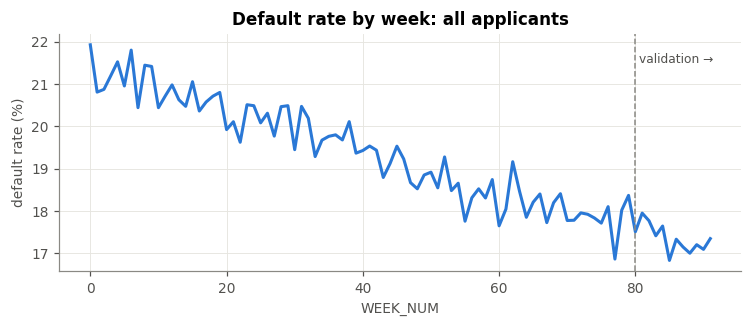

In [52]:
# Weekly default rate over the whole training window (context only: weeks ≥ 80 are validation)
weekly = app.groupby("WEEK_NUM")["target"].mean()
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.plot(weekly.index, weekly.values * 100, color=C_EST, lw=2)
ax.axvline(VALID_START_WEEK, color="#8a8984", ls="--", lw=1)     # start of the validation window
ax.text(VALID_START_WEEK + 0.5, ax.get_ylim()[1] * 0.98, "validation →", va="top", fontsize=8, color="#52514e")
ax.set(title="Default rate by week: all applicants", xlabel="WEEK_NUM", ylabel="default rate (%)")
plt.show()

## 3. Missingness per table and column

Two questions: **how much** is missing, and **does being missing predict default?** If it does, the gap is a signal and
deserves a flag. If it doesn't, the gap is noise, and imputing it is enough.

In [53]:
# For every column with gaps: % missing, and the default rate when the value is missing vs present.
# For depth-1/2 tables the rates are row-level, so applicants with many rows count more.
miss_rows = []
for name in TABLES:
    d = train[name]
    gap_cols = [c for c in d.columns if d[c].isna().any()]
    if not gap_cols:
        continue
    # Attach the target once per table; the inner join keeps fit-week applicants only
    m = d[["case_id", *gap_cols]].merge(fit[["case_id", "target"]], on="case_id")
    for col in gap_cols:
        is_na = m[col].isna()
        miss_rows.append({
            "table": name, "column": col, "pct_missing": round(d[col].isna().mean() * 100, 2),
            "default_rate_if_missing": round(m.loc[is_na, "target"].mean() * 100, 2),
            "default_rate_if_present": round(m.loc[~is_na, "target"].mean() * 100, 2),
        })
missing = pd.DataFrame(miss_rows)
missing["gap_pts"] = (missing["default_rate_if_missing"] - missing["default_rate_if_present"]).round(2)  # > 0: missing = riskier
print("Only columns with at least one missing value are listed. Every unlisted column is complete.")
missing

Only columns with at least one missing value are listed. Every unlisted column is complete.


,table,column,pct_missing,default_rate_if_missing,default_rate_if_present,gap_pts
0,static_0,mainoccupationinc_384A,4.97,19.24,19.46,-0.22
1,static_0,credamount_770A,2.00,19.25,19.45,-0.20
2,static_0,annuity_780A,9.97,19.59,19.43,0.16
3,static_0,days_employed_700P,15.06,19.57,19.43,0.14
4,static_cb_0,riskassesment_940T,5.02,16.58,16.41,0.17
5,person_1,mainoccupationinc_384A,5.00,19.37,19.46,-0.09
6,person_1,empl_employedtotal_800L,19.98,19.47,19.45,0.02
7,credit_bureau_a_1,overdueamountmax_950A,29.98,16.49,16.40,0.09
8,applprev_1,approvaldate_319D,10.00,19.50,19.51,-0.01
9,credit_bureau_a_2,pmts_overdue_1140A,40.01,16.43,16.43,0.00


**Within the tables, values are missing at random.** Every column with gaps (2–40% missing) has the same default rate
whether the value is there or not (gaps of at most 0.22 points). Row-level missingness carries **no signal** here.
(For depth-1/2 tables these rates are per row, so applicants with many rows weigh more.)

What *does* carry signal is **table-level absence**: having no rows at all in the bureau tables (next section). So:
- The catalog's `missing_income`, `missing_annuity` and `missing_days_employed` flags should add nothing. They're cheap to keep, but don't expect lift.
- `missing_overdue` is useful only because it's ~1 for thin-file applicants, which repeats `thin_file`.
- `riskassesment_940T` is 5% missing *among bureau applicants*, also at random.

## 4. Segments: thin-file vs established

In [54]:
# Segment sizes and default rates on fit weeks
seg = fit.groupby("segment").agg(applicants=("target", "size"), default_rate=("target", "mean"))
seg["share"] = seg["applicants"] / seg["applicants"].sum()
print(seg.assign(default_rate_pct=lambda s: (s.default_rate * 100).round(1), share_pct=lambda s: (s.share * 100).round(1))
         .drop(columns=["default_rate", "share"]))

# Is the thin-file share the same in test? (label-free). The test tables loaded here are reused in section 9.
test_base = read_table("test", "base")
test_cb1 = read_table("test", "credit_bureau_a_1")
test_thin = 1 - test_base["case_id"].isin(test_cb1["case_id"]).mean()
print(f"\ntest applicants: {len(test_base):,}")
print(f"thin-file share  train: {app['thin_file'].mean():.1%}   test: {test_thin:.1%}   (stable, so the segment mix doesn't shift)")

             applicants  default_rate_pct  share_pct
segment                                             
established      608739              16.4       70.0
thin-file        260820              26.5       30.0

test applicants: 200,000
thin-file share  train: 30.0%   test: 30.0%   (stable, so the segment mix doesn't shift)


### Bureau coverage: does *how much* history matter, or only *whether* there is any?

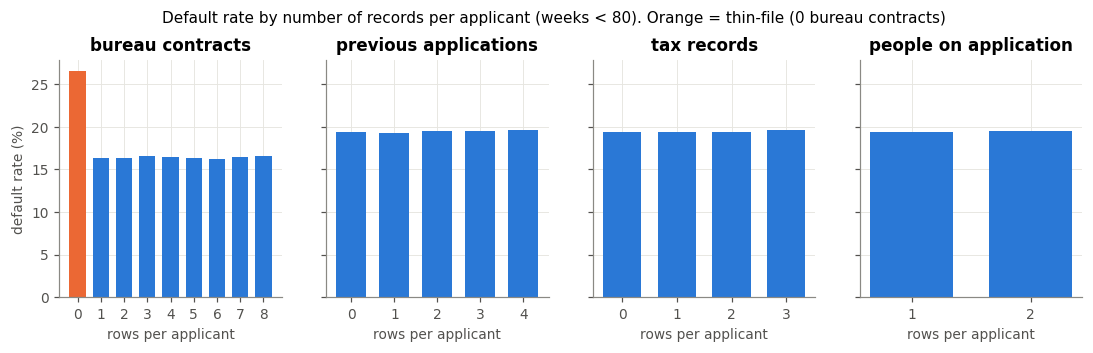

bureau contracts         0: 26.5% (n=260,820) | 1: 16.3% (n=75,714) | 2: 16.4% (n=75,928) | 3: 16.6% (n=75,978) | 4: 16.5% (n=75,876) | 5: 16.4% (n=76,186) | 6: 16.3% (n=76,196) | 7: 16.4% (n=76,440) | 8: 16.5% (n=76,421)
previous applications    0: 19.4% (n=174,025) | 1: 19.3% (n=174,496) | 2: 19.5% (n=173,950) | 3: 19.5% (n=173,334) | 4: 19.6% (n=173,754)
tax records              0: 19.4% (n=217,571) | 1: 19.4% (n=217,182) | 2: 19.4% (n=217,671) | 3: 19.6% (n=217,135)
people on application    1: 19.4% (n=434,303) | 2: 19.5% (n=435,256)


In [55]:
# Default rate by how many rows an applicant has in each table (0 = absent from that table)
coverage = {}
for col, label in [("cb1_count", "bureau contracts"), ("prev_count", "previous applications"),
                   ("tax_count", "tax records"), ("person_count", "people on application")]:
    coverage[label] = fit.groupby(col)["target"].agg(applicants="size", default_rate="mean")

fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), sharey=True)
for ax, (label, t) in zip(axes, coverage.items()):
    # Highlight the thin-file bar (0 bureau contracts) in the segment color
    colors = [C_THIN if (label == "bureau contracts" and k == 0) else C_EST for k in t.index]
    ax.bar(t.index.astype(str), t["default_rate"] * 100, color=colors, width=0.7)
    ax.set(title=label, xlabel="rows per applicant")
axes[0].set_ylabel("default rate (%)")
fig.suptitle("Default rate by number of records per applicant (weeks < 80). Orange = thin-file (0 bureau contracts)",
             fontsize=10, y=1.04)
plt.show()

# Same numbers as text, with group sizes so small bars can be judged
for label, t in coverage.items():
    print(f"{label:24s}", " | ".join(f"{k}: {r.default_rate:.1%} (n={int(r.applicants):,})" for k, r in t.iterrows()))

**Only one coverage fact matters: having any bureau history at all.** Thin-file applicants (0 contracts) default far more often.
Among established applicants, 1 contract and 8 contracts carry the **same** risk. The number of previous applications,
tax records and people on the application don't move the default rate at all.

*For feature engineering:* `thin_file` is the signal. `has_prev`, `has_tax`, `has_coapplicant`, `person_count` and the raw
record counts are flat in this data, so they shouldn't be expected to help.

In [56]:
# Within each segment, does having previous applications or tax records change the default rate?
combo = (fit.assign(has_prev=fit["prev_count"] > 0, has_tax=fit["tax_count"] > 0)
            .groupby(["segment", "has_prev", "has_tax"])["target"].agg(applicants="size", default_rate="mean"))
combo["default_rate"] = (combo["default_rate"] * 100).round(1)
combo

applicants  default_rate
segment     has_prev has_tax                          
established False    False         30706          16.4
                     True          91158          16.3
            True     False        121609          16.3
                     True         365266          16.5
thin-file   False    False         13104          26.6
                     True          39057          26.4
            True     False         52152          26.6
                     True         156507          26.5

### Drift: the thin-file default rate falls over time; the established rate doesn't

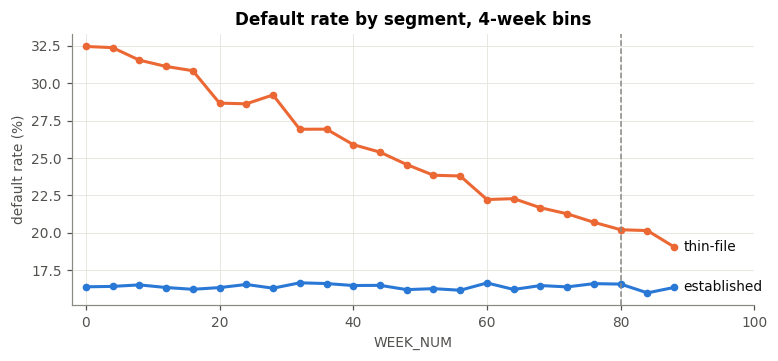

segment           established  thin-file  first_date   last_date
quarter_of_train                                                
0                        16.4       31.2  2019-01-01  2019-06-04
1                        16.5       27.5  2019-06-11  2019-11-12
2                        16.3       23.4  2019-11-19  2020-04-21
3                        16.4       20.5  2020-04-28  2020-09-29


In [57]:
# Default rate per segment in 4-week bins over all training weeks (validation weeks shown for context)
drift = (app
         .assign(period=lambda d: d["WEEK_NUM"] // 4 * 4)          # 0, 4, 8, ... = first week of each bin
         .groupby(["period", "segment"])["target"].mean().unstack() * 100)

fig, ax = plt.subplots(figsize=(8, 3.2))
for segname, color in [("established", C_EST), ("thin-file", C_THIN)]:
    ax.plot(drift.index, drift[segname], color=color, lw=2, marker="o", ms=4)
    # Label each line at its right end instead of using a legend
    ax.annotate(segname, (drift.index[-1], drift[segname].iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color="#0b0b0b")
ax.axvline(VALID_START_WEEK, color="#8a8984", ls="--", lw=1)
ax.set(title="Default rate by segment, 4-week bins", xlabel="WEEK_NUM", ylabel="default rate (%)",
       xlim=(-2, 100))
plt.show()

# The same view in four 23-week blocks (weeks 0-22, 23-45, 46-68, 69-91) for a compact table
q = app.assign(quarter_of_train=lambda d: d["WEEK_NUM"] // 23)
block = (q.groupby(["quarter_of_train", "segment"])["target"].mean().unstack() * 100).round(1)
block[["first_date", "last_date"]] = q.groupby("quarter_of_train")["date_decision"].agg(["min", "max"]).apply(lambda s: s.dt.date).to_numpy()
print(block)

This is the problem the challenge is built around:
- **Established**: flat at ~16.4% in every period.
- **Thin-file**: falls steadily from ~31% (Jan–Jun 2019) to ~20.5% (Apr–Sep 2020, the last block, which includes the validation weeks),
  already next to the 20% break-even line. The test weeks (92–107) come later; *if* the trend continues, which the data can't confirm,
  thin-file risk there is even lower.

A model trained on all weeks equally learns the thin-file **average** (≈ 26%), so it will **over-estimate** thin-file PD on test
and deny people who would repay. Next question: is the drift in the *applicants* (features) or only in the *outcome*?

In [58]:
# Did the thin-file applicants themselves change over time? Compare feature means per block
thin_q = q[q["thin_file"] == 1]
feat_drift = thin_q.groupby("quarter_of_train")[
    ["mainoccupationinc_384A", "credamount_770A", "annuity_780A", "days_employed_700P", "age_years",
     "tax_amount_4527230A_mean", "person_empl_employedtotal_800L_mean"]].mean().round(1)
feat_drift["default_rate_%"] = (thin_q.groupby("quarter_of_train")["target"].mean() * 100).round(1)
display(feat_drift)

# Education mix of thin-file applicants per block (row %)
print("thin-file education mix per block (%):")
print((pd.crosstab(thin_q["quarter_of_train"], thin_q["education_927M"], normalize="index") * 100).round(1))

,mainoccupationinc_384A,credamount_770A,annuity_780A,days_employed_700P,age_years,tax_amount_4527230A_mean,person_empl_employedtotal_800L_mean,default_rate_%
quarter_of_train,,,,,,,,
0,24416.2,16754.2,1245.3,1526.6,45.6,24000.6,60.3,31.2
1,24433.7,16693.5,1245.4,1523.3,46.2,24001.1,60.2,27.5
2,24535.8,16710.6,1244.3,1520.0,46.6,24076.8,60.3,23.4
3,24447.1,16787.9,1244.3,1526.2,46.9,23981.1,60.1,20.5


thin-file education mix per block (%):
education_927M    10795bac  242b264b  2d4a2bc4  6def22f0  f937ecaa
quarter_of_train                                                  
0                     21.7      21.9      14.3      28.0      14.1
1                     21.6      22.1      14.2      27.9      14.1
2                     21.5      21.8      14.3      28.3      14.1
3                     21.6      21.9      14.2      28.1      14.2


### Is it only the baseline that moves?

Flat feature means rule out covariate drift, but "prior drift" also needs the **feature → risk relationship** to stay put.
If each feature ranks thin-file risk equally well in every block, only the baseline is moving and recalibration is the fix.
If the AUCs move too, the relationship itself is changing (concept drift) and retraining on recent weeks matters more.

In [59]:
# The strongest features thin-file applicants actually have (see section 7); reused in later cells
thin_feats = ["tax_amount_4527230A_mean", "days_employed_700P", "person_empl_employedtotal_800L_mean",
              "person_mainoccupationinc_384A_mean", "prev_credamount_590A_mean", "mainoccupationinc_384A"]

# Univariate AUC of each feature inside thin-file, separately per 23-week block
stability = pd.DataFrame({blk: {c: uni_auc(g, c)[0] for c in thin_feats}
                          for blk, g in thin_q.groupby("quarter_of_train")}).round(3)
stability.columns.name = "quarter_of_train"
stability["range"] = stability.max(axis=1) - stability.min(axis=1)    # how much the AUC moves across blocks
stability

quarter_of_train,0,1,2,3,range
tax_amount_4527230A_mean,0.584,0.591,0.589,0.589,0.007
days_employed_700P,0.577,0.575,0.575,0.575,0.002
person_empl_employedtotal_800L_mean,0.564,0.574,0.568,0.565,0.010
person_mainoccupationinc_384A_mean,0.560,0.560,0.560,0.557,0.003
prev_credamount_590A_mean,0.556,0.559,0.555,0.552,0.007
mainoccupationinc_384A,0.554,0.554,0.555,0.554,0.001


**The thin-file applicants don't change. Only their outcomes do.** Income, credit amount, employment, age and tax income stay flat
across the blocks (education mix too, within 0.4 points), while the default rate falls about 10 points. And each feature ranks
thin-file risk equally well in every block (AUC moves by ≤ 0.01). That's **label/prior drift**, not covariate or concept drift:
only the baseline moves. What it implies:
- More features can't fix it, because the features can't "see" the drift.
- What fixes it: **recency weighting** (weight later weeks more), a **time-aware intercept** for thin-file, and **per-segment
  calibration on the latest weeks** (the catalog's lever #1). Validation on weeks 80–91 will show it, so report per-segment calibration there.

## 5. Numeric distributions, skew, outliers and sentinels

In [60]:
# Every numeric measurement column in every table (keys, indices, time and target excluded)
id_cols = {"case_id", "num_group1", "num_group2", "personindex_1023L", "WEEK_NUM", "MONTH", "target"}
stats = []
for name, d in train.items():
    for c in d.select_dtypes("number").columns.difference(id_cols, sort=False):
        s = d[c].dropna()
        p01, p50, p99 = s.quantile([0.01, 0.5, 0.99])
        stats.append({"table": name, "column": c, "n": len(s), "mean": s.mean(), "p01": p01, "median": p50,
                      "p99": p99, "max": s.max(),
                      "max/p99": s.max() / p99 if p99 else np.nan,        # how far the max sits past the bulk
                      "skew": s.skew(), "pct_zero": (s == 0).mean() * 100,
                      "n_negative": int((s < 0).sum()),
                      "n_365243": int((s == 365243).sum())})              # Home Credit's "missing date" sentinel
num_stats = pd.DataFrame(stats).set_index(["table", "column"])
print(f"{len(num_stats)} numeric columns checked across {num_stats.index.get_level_values('table').nunique()} tables")
num_stats.round(2)

15 numeric columns checked across 7 tables


n      mean      p01   median       p99        max  max/p99  skew  pct_zero  n_negative  n_365243
table             column                                                                                                                          
static_0          mainoccupationinc_384A    950349  24477.42  7516.00  22021.0  64417.56  174473.00     2.71  1.59      0.00           0         0
                  credamount_770A           980041  16730.81  4610.00  14760.0  47330.00  150395.00     3.18  1.75      0.00           0         0
                  annuity_780A              900323   1242.75   342.00   1097.0   3505.00   12069.00     3.44  1.75      0.00           0         0
                  days_employed_700P        849429   1524.35     0.00   1502.0   3711.00    5852.00     1.58  0.26      5.69           0         0
static_cb_0       riskassesment_940T        665035      0.50     0.09      0.5      0.91       0.99     1.09 -0.00      0.00           0         0
                  numberofqueries_146L      700179      3.00     0.00      3.0      9.00      18.00     2.00  0.76      8.14           0         0
person_1          mainoccupationinc_384A   1425252  24493.41  7545.51  22030.0  64356.00  203989.00     3.17  1.56      0.00           0         0
                  empl_employedtotal_800L  1200496     60.31     0.00     60.0    132.40     213.60     1.61  0.14      2.70           0         0
credit_bureau_a_1 credamount_770A          3155263  15443.02  3817.00  13361.0  46741.00  236011.00     5.05  1.93      0.00           0         0
                  overdueamountmax_950A    2209254    288.78     0.00    200.0   1194.00    2252.00     1.89  1.05     32.02           0         0
                  pmts_dpdvalue_108P       3155263      9.70     0.00      8.0     35.10      67.60     1.93  0.83     24.82           0         0
applprev_1        credamount_590A          1997547   9745.49  1974.00   8100.0  33426.54  184868.00     5.53  2.31      0.00           0         0
tax_registry_a_1  amount_4527230A          1499786  24021.72  8335.00  22027.0  58076.00  185045.00     3.19  1.39      0.00           0         0
credit_bureau_a_2 pmts_month_158T          4729114      6.50     1.00      7.0     12.00      12.00     1.00  0.00      0.00           0         0
                  pmts_overdue_1140A       2836862     76.94     0.00     50.0    329.00     651.00     1.98  1.10     34.00           0         0

- **No 365243 sentinel and no negative values in any of the 15 numeric columns**: nothing to recode, unlike the original Home Credit data.
- **Amounts (`…A`) are right-skewed** (skew ≈ 1.4–2.3; max is 2.7–5.5× the 99th percentile). The values are plausible, so
  **log1p + capping** (notebook 03's winsorizing) is the right treatment. Logistic regression needs it; trees don't.
- **Zero-inflated delinquency**: `overdueamountmax_950A` and `pmts_overdue_1140A` are 0 for about a third of non-missing rows, which is "never overdue".
  A binary `ever_overdue` flag plus the amount describes that better than the amount alone.
- `days_employed_700P` ranges 0–5,852 days (0–16 years). The `…P` suffix is misleading here: it's a tenure, not days-past-due.

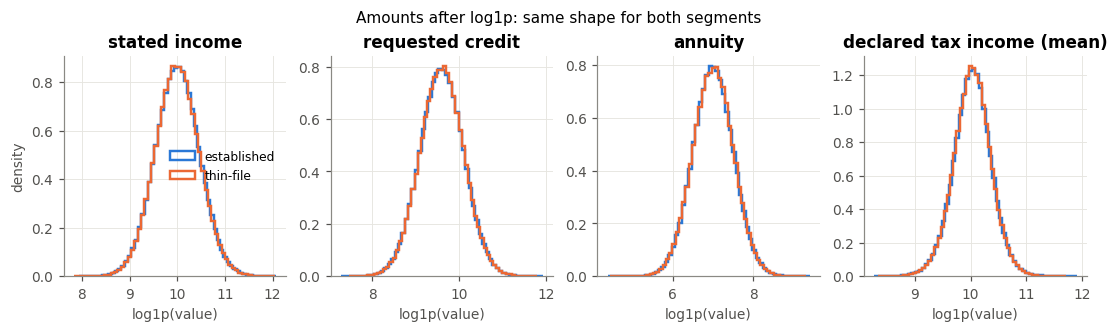

In [61]:
# Overlay the two segments' distributions on a log1p scale (density, so different segment sizes compare fairly)
fig, axes = plt.subplots(1, 4, figsize=(12, 2.6))
for ax, (col, label) in zip(axes, [("mainoccupationinc_384A", "stated income"), ("credamount_770A", "requested credit"),
                                   ("annuity_780A", "annuity"), ("tax_amount_4527230A_mean", "declared tax income (mean)")]):
    for segname, color in [("established", C_EST), ("thin-file", C_THIN)]:
        v = np.log1p(app.loc[app["segment"] == segname, col].dropna())
        ax.hist(v, bins=60, density=True, histtype="step", lw=1.6, color=color, label=segname)
    ax.set(title=label, xlabel="log1p(value)")
axes[0].set_ylabel("density"); axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Amounts after log1p: same shape for both segments", fontsize=10, y=1.04)
plt.show()

Thin-file and established applicants have the **same distributions** of income, loan size, annuity and tax income. Thin-file applicants aren't poorer or asking for more. They just have no bureau record.

## 6. Categorical features: cardinality, rare levels, default rate by category

In [62]:
# Every text column except dates (…D) is a categorical; find them all instead of hand-picking
cat_specs = [(name, c) for name, d in train.items() for c in d.select_dtypes("object").columns
             if not c.endswith("D") and c != "date_decision"]
print(f"{len(cat_specs)} categorical columns found:", ", ".join(c for _, c in cat_specs))

cat_rows, cat_detail = [], {}
for name, col in cat_specs:
    # Default rate per level on fit weeks (row-level for depth-1 tables)
    d = train[name][["case_id", col]].merge(fit[["case_id", "target"]], on="case_id")
    by = d.groupby(col)["target"].agg(rows="size", default_rate="mean").sort_values("default_rate")
    by["share"] = by["rows"] / by["rows"].sum()
    cat_detail[col] = by
    cat_rows.append({"table": name, "column": col, "levels": len(by), "pct_missing": train[name][col].isna().mean() * 100,
                     "top_level_share_%": by["share"].max() * 100, "rarest_level_share_%": by["share"].min() * 100,
                     "default_rate_min_%": by["default_rate"].min() * 100, "default_rate_max_%": by["default_rate"].max() * 100})
cats = pd.DataFrame(cat_rows).set_index("column")
cats["spread_pts"] = cats["default_rate_max_%"] - cats["default_rate_min_%"]   # how far apart the riskiest and safest levels are
cats.sort_values("spread_pts", ascending=False).round(1)

7 categorical columns found: education_927M, maritalstatus_703M, description_5085714M, housingtype_772M, classificationofcontr_13M, status_219L, name_4527232M


,table,levels,pct_missing,top_level_share_%,rarest_level_share_%,default_rate_min_%,default_rate_max_%,spread_pts
column,,,,,,,,
education_927M,static_0,5,0.0,27.9,14.1,4.0,47.3,43.3
classificationofcontr_13M,credit_bureau_a_1,6,0.0,20.5,14.1,2.4,44.3,41.9
description_5085714M,static_cb_0,6,0.0,20.4,14.1,2.5,44.3,41.8
name_4527232M,tax_registry_a_1,10,0.0,10.0,10.0,19.3,19.6,0.3
maritalstatus_703M,static_0,4,0.0,25.1,24.9,19.3,19.5,0.2
housingtype_772M,person_1,5,0.0,20.0,20.0,19.4,19.5,0.2
status_219L,applprev_1,3,0.0,33.4,33.3,19.4,19.5,0.1


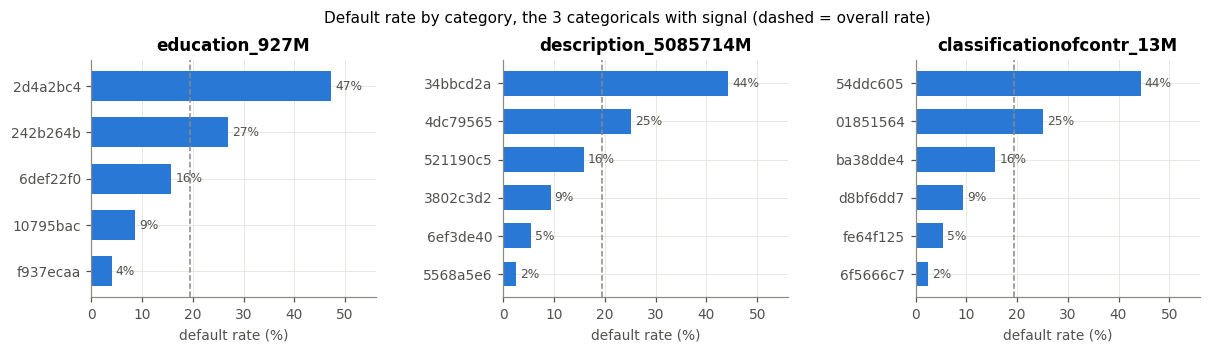

education mix by segment (does thin-file differ?):
education_927M  10795bac  242b264b  2d4a2bc4  6def22f0  f937ecaa
segment                                                         
established         21.9      21.8      14.2      27.9      14.2
thin-file           21.6      21.9      14.3      28.1      14.1

education default rate by segment:
segment         established  thin-file
education_927M                        
10795bac                6.0       14.5
242b264b               23.1       36.1
2d4a2bc4               44.3       54.2
6def22f0               12.3       23.8
f937ecaa                2.5        7.6


In [63]:
# Default rate per level for the three categoricals that show signal
signal_cats = ["education_927M", "description_5085714M", "classificationofcontr_13M"]
fig, axes = plt.subplots(1, 3, figsize=(13, 2.8), sharex=True, gridspec_kw={"wspace": 0.45})
for ax, col in zip(axes, signal_cats):
    t = cat_detail[col]
    ax.barh(t.index, t["default_rate"] * 100, color=C_EST, height=0.65)
    ax.axvline(fit["target"].mean() * 100, color="#8a8984", ls="--", lw=1)     # overall default rate
    for y, v in enumerate(t["default_rate"] * 100):
        ax.text(v + 0.8, y, f"{v:.0f}%", va="center", fontsize=8, color="#52514e")
    ax.set(title=col, xlabel="default rate (%)", xlim=(0, 56))
fig.suptitle("Default rate by category, the 3 categoricals with signal (dashed = overall rate)", fontsize=10, y=1.04)
plt.show()

# Education is available for everyone: does its mix or its signal differ between segments?
print("education mix by segment (does thin-file differ?):")
print((pd.crosstab(fit["segment"], fit["education_927M"], normalize="index") * 100).round(1))
print("\neducation default rate by segment:")
print((fit.pivot_table(index="education_927M", columns="segment", values="target") * 100).round(1))

- **All 7 categoricals are low-cardinality** (3–10 levels), complete (0% missing) and well balanced. The rarest level still holds ≥ 10% of rows,
  so there's nothing to pool into "OTHER" and one-hot encoding is safe. (The catalog's "rare categories pooled" step won't trigger.)
- **Three carry strong signal**: `education_927M` (4% → 47% default across levels), `description_5085714M` and `classificationofcontr_13M`.
- **Four carry none**: `maritalstatus_703M`, `housingtype_772M`, `status_219L` and `name_4527232M` all sit at 19.3–19.6% in every level.
  That matches the feature catalog's screen, which dropped them.
- **Education is the thin-file applicants' strongest categorical**: it's available for everyone, has the same mix in both segments, and
  separates risk within thin-file just as well (7.6% → 54.2% default across levels, vs 2.5% → 44.3% for established).
  Inside thin-file it reaches AUC ≈ 0.70 on its own (section 7), the strongest thin-file signal by far.

## 7. Which features separate repay vs default, by segment

Univariate ROC-AUC of each numeric feature against `target` (weeks < 80, missing values skipped). Reported as
`max(AUC, 1 − AUC)`, so 0.5 = no signal and higher = stronger, whatever the direction. `direction` says whether a higher value means **more** or **less** risk.

This is the key table for the inclusion gap: what still works **inside the thin-file segment**, where every bureau feature is empty?

In [64]:
# Score every numeric feature on all applicants, then inside each segment separately (uni_auc is defined in the setup cell)
skip = {"case_id", "target", "WEEK_NUM", "MONTH", "thin_file", "num_group1", "personindex_1023L"}
num_feats = [c for c in fit.select_dtypes("number").columns if c not in skip and not c.endswith("_count")]
rows = []
for c in num_feats:
    a_all, direction = uni_auc(fit, c)
    a_est, _ = uni_auc(fit[fit["thin_file"] == 0], c)
    a_thin, _ = uni_auc(fit[fit["thin_file"] == 1], c)     # NaN for bureau features: thin-file has no values
    rows.append({"feature": c, "AUC_all": a_all, "AUC_established": a_est, "AUC_thin_file": a_thin, "direction": direction})
signal = pd.DataFrame(rows).set_index("feature")
signal["available_for_thin_file"] = signal["AUC_thin_file"].notna()
# Bureau-only features first, then the ones thin-file applicants also have, each block strongest first
signal.sort_values(["available_for_thin_file", "AUC_all"], ascending=[True, False]).round(3)

,AUC_all,AUC_established,AUC_thin_file,direction,available_for_thin_file
feature,,,,,
riskassesment_940T,0.798,0.798,NaN,higher → riskier,False
cb1_pmts_dpdvalue_108P_mean,0.715,0.715,NaN,higher → riskier,False
cb1_pmts_dpdvalue_108P_max,0.676,0.676,NaN,higher → riskier,False
cb1_credamount_770A_mean,0.675,0.675,NaN,higher → riskier,False
cb1_pmts_dpdvalue_108P_sum,0.661,0.661,NaN,higher → riskier,False
cb1_pmts_dpdvalue_108P_min,0.649,0.649,NaN,higher → riskier,False
cb1_overdueamountmax_950A_mean,0.648,0.648,NaN,higher → riskier,False
numberofqueries_146L,0.645,0.645,NaN,higher → riskier,False
cb1_credamount_770A_min,0.632,0.632,NaN,higher → riskier,False


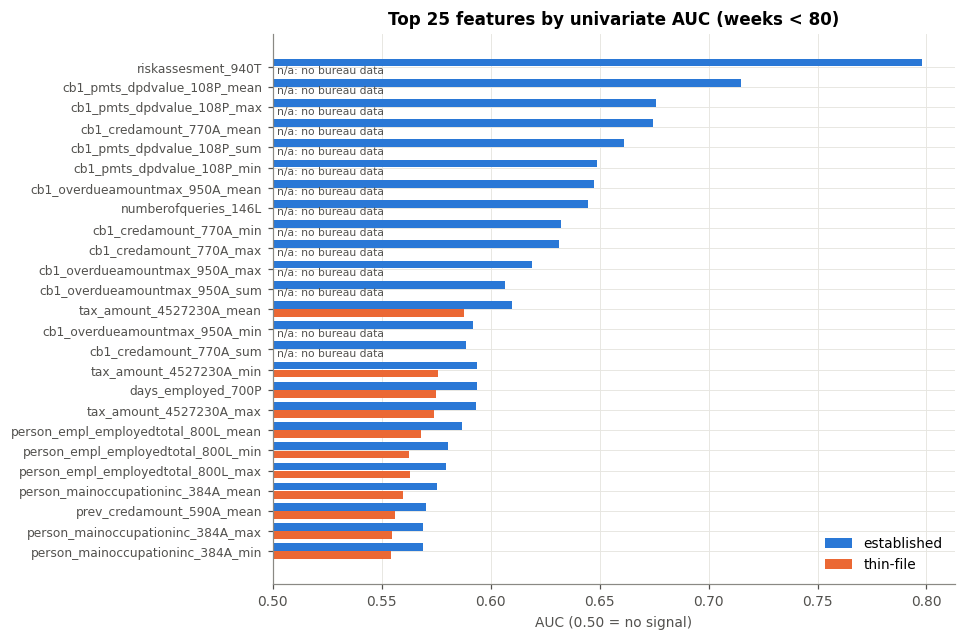

In [65]:
# Paired bars per feature: established vs thin-file AUC, drawn as distance from 0.5 so "no signal" sits at the axis
top = signal.sort_values("AUC_all", ascending=False).head(25).iloc[::-1]     # reversed so the strongest is on top
fig, ax = plt.subplots(figsize=(8, 6.5))
y = np.arange(len(top))
ax.barh(y + 0.2, top["AUC_established"] - 0.5, height=0.38, color=C_EST, label="established")
ax.barh(y - 0.2, (top["AUC_thin_file"] - 0.5).fillna(0), height=0.38, color=C_THIN, label="thin-file")
for yi, (f, r) in zip(y, top.iterrows()):
    if np.isnan(r["AUC_thin_file"]):
        ax.text(0.002, yi - 0.2, "n/a: no bureau data", va="center", fontsize=7, color="#52514e")
ax.set_yticks(y, top.index, fontsize=8)
ax.set_xticks(np.arange(0, 0.31, 0.05), [f"{0.5 + t:.2f}" for t in np.arange(0, 0.31, 0.05)])   # relabel as real AUC
ax.set(title="Top 25 features by univariate AUC (weeks < 80)", xlabel="AUC (0.50 = no signal)")
ax.legend(frameon=False, loc="lower right")
plt.show()

**What the signal table shows**

1. **Bureau features dominate**: `riskassesment_940T` (AUC ≈ 0.80) is the strongest single feature, followed by days-past-due
   (`cb1_pmts_dpdvalue_108P_mean` ≈ 0.72), past contract size and overdue amounts, and `numberofqueries_146L`. Thin-file applicants
   have **none** of them. That's the "flying blind" problem in one picture.
2. **Thin-file applicants still have usable signal**, just weaker (AUC 0.55–0.59 each): **declared tax income**, **employment
   length** (`days_employed_700P` and person-level `empl_employedtotal_800L`), **person-level income**, **previous-application amounts**
   and **stated income**. Each one predicts *almost as well* inside thin-file as inside established. These signals don't depend on the bureau.
   The thin-file model should be built from these plus `education_927M`, which is much stronger than any of them (see the check below).
3. **Zero signal (AUC ≈ 0.50)**: `credamount_770A`, `annuity_780A`, `implied_term`, `age_years`, and every
   `credit_bureau_a_2` aggregate (`pmts_overdue_1140A`, `pmts_month_158T`). Requested loan size doesn't predict default here by itself.
   `leverage` and `payment_burden` only work because income is their denominator.
4. **Direction checks out**: more income, tax income, tenure and prior credit → safer. More days-past-due, overdue amounts and queries → riskier.

### Default rate across deciles: the strongest features that thin-file applicants actually have

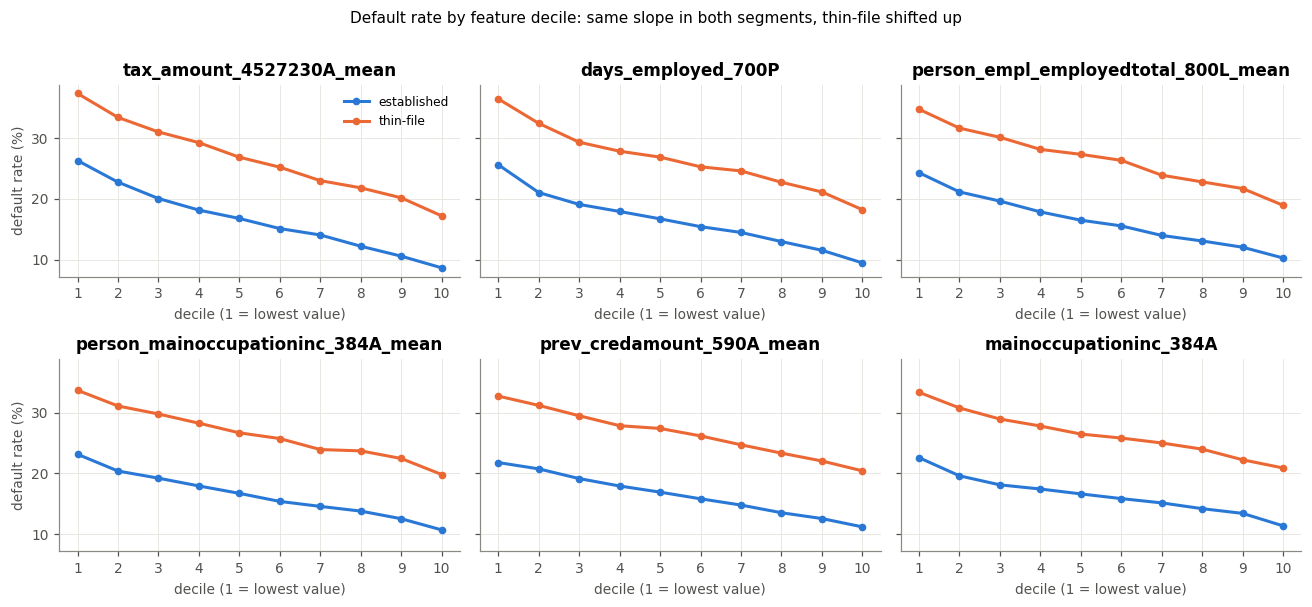

thin-file minus established, log-odds gap across deciles:
                                     mean   min   max
tax_amount_4527230A_mean             0.63  0.51  0.79
days_employed_700P                   0.63  0.51  0.76
person_empl_employedtotal_800L_mean  0.63  0.51  0.71
person_mainoccupationinc_384A_mean   0.62  0.52  0.72
prev_credamount_590A_mean            0.62  0.55  0.71
mainoccupationinc_384A               0.62  0.54  0.72


In [66]:
# Default rate per decile of each thin-file feature (thin_feats is defined in section 4), one line per segment
fig, axes = plt.subplots(2, 3, figsize=(12, 5.4), sharey=True)
gaps = {}
for ax, col in zip(axes.flat, thin_feats):
    d = fit.loc[fit[col].notna(), [col, "segment", "target"]]
    # Decile edges come from the pooled data, so decile k covers the same value range in both segments
    dec = pd.qcut(d[col], 10, labels=False, duplicates="drop")
    r = d.groupby([dec, "segment"])["target"].mean().unstack()
    for segname, color in [("established", C_EST), ("thin-file", C_THIN)]:
        ax.plot(r.index + 1, r[segname] * 100, color=color, lw=2, marker="o", ms=4, label=segname)
    ax.set(title=col, xlabel="decile (1 = lowest value)")
    ax.set_xticks(range(1, 11))
    # Segment gap on the log-odds scale: a constant gap means thin-file is a pure intercept shift
    logit = np.log(r / (1 - r))
    gaps[col] = (logit["thin-file"] - logit["established"]).agg(["mean", "min", "max"])
for ax in axes[:, 0]:
    ax.set_ylabel("default rate (%)")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Default rate by feature decile: same slope in both segments, thin-file shifted up", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

print("thin-file minus established, log-odds gap across deciles:")
print(pd.DataFrame(gaps).T.round(2))

The curves for the two segments run **parallel**: each feature ranks risk the same way in both, and the thin-file line sits higher
by a roughly constant amount: about **+0.62 in log-odds** for every feature, varying only 0.5–0.8 across deciles. So the relationship holds in both segments. Thin-file applicants mainly differ in their *baseline* risk, and that baseline is drifting (section 4).

### Several noisy views of the same applicant

The same quantity shows up in several tables: stated income (`static_0`), person-level income (`person_1`), declared tax income
(`tax_registry_a_1`). Do they agree?

In [67]:
# The primary applicant's own row in person_1 is num_group1 == 0
p0 = train["person_1"].query("num_group1 == 0")[["case_id", "mainoccupationinc_384A", "empl_employedtotal_800L"]] \
        .rename(columns={"mainoccupationinc_384A": "person0_income", "empl_employedtotal_800L": "person0_empl"})
views = fit.merge(p0, on="case_id", how="left")
# Spearman (rank) correlation: robust to the right-skewed amounts, and consistent with section 8
print(views[["mainoccupationinc_384A", "person0_income", "tax_amount_4527230A_mean"]].corr(method="spearman").round(3))
print()
print(views[["days_employed_700P", "person0_empl"]].corr(method="spearman").round(3))

                          mainoccupationinc_384A  person0_income  tax_amount_4527230A_mean
mainoccupationinc_384A                     1.000           0.045                     0.074
person0_income                             0.045           1.000                     0.075
tax_amount_4527230A_mean                   0.074           0.075                     1.000

                    days_employed_700P  person0_empl
days_employed_700P               1.000         0.076
person0_empl                     0.076         1.000


They barely agree (Spearman ρ ≈ 0.05–0.08), even for the primary applicant's own income. Yet each one predicts default about
equally well. In this synthetic data they behave like **independent noisy readings of one hidden "creditworthiness"**. That helps
the thin-file segment: **combining** them (all incomes, all tenures, tax income, prior amounts, education) should rank thin-file
applicants better than any single one (tested below). Don't drop any as "duplicates". The tax ÷ stated income ratio
(`tax_to_stated_income` here, `income_consistency` in the catalog) isn't meaningful (AUC 0.51), because the two numbers aren't measuring the same thing for the same person.

### Does combining them actually help? A quick thin-file-only model

The claim above is testable. Fit a plain logistic regression on **thin-file applicants, weeks < 80**, using only the non-bureau
features plus `education_927M`, and score **thin-file applicants in weeks 80–91**. Compare with each feature on its own on the same weeks.
This isn't the team's model; it only checks whether the signals add up.

In [68]:
combo_num, combo_cat = thin_feats, ["education_927M"]
tr = fit[fit["thin_file"] == 1]
va = valid[valid["thin_file"] == 1]

# Numeric: fill gaps with the median, log1p the skewed amounts, standardize. Categorical: one-hot.
prep = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(np.log1p), StandardScaler()), combo_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), combo_cat),
])
model = make_pipeline(prep, LogisticRegression(max_iter=1_000)).fit(tr[combo_num + combo_cat], tr["target"])
auc_combined = roc_auc_score(va["target"], model.predict_proba(va[combo_num + combo_cat])[:, 1])

# Same model without education, to see how much the numeric signals add up to on their own
model_num = make_pipeline(clone(prep).set_params(cat="drop"), LogisticRegression(max_iter=1_000)).fit(tr[combo_num + combo_cat], tr["target"])
auc_numeric = roc_auc_score(va["target"], model_num.predict_proba(va[combo_num + combo_cat])[:, 1])

# Single-feature AUCs on the same validation rows (education scored by its fit-week default rate per level)
single = {c: uni_auc(va, c)[0] for c in thin_feats}
edu_rate = tr.groupby("education_927M")["target"].mean()
single["education_927M"] = roc_auc_score(va["target"], va["education_927M"].map(edu_rate))
single = pd.Series(single, name="AUC, thin-file weeks 80-91").sort_values(ascending=False)
print(single.round(3).to_string())
print(f"\nlogistic regression, numeric features only:   AUC = {auc_numeric:.3f}   (best single numeric {single.drop('education_927M').max():.3f})")
print(f"logistic regression, numeric + education:     AUC = {auc_combined:.3f}   (education alone {single['education_927M']:.3f})")

education_927M                         0.702
tax_amount_4527230A_mean               0.585
days_employed_700P                     0.574
person_empl_employedtotal_800L_mean    0.565
mainoccupationinc_384A                 0.557
person_mainoccupationinc_384A_mean     0.553
prev_credamount_590A_mean              0.550

logistic regression, numeric features only:   AUC = 0.616   (best single numeric 0.585)
logistic regression, numeric + education:     AUC = 0.708   (education alone 0.702)


**Combining helps, but education does most of the work.**
- The six numeric signals together reach **AUC ≈ 0.62**, clearly above the best one alone (0.585), so they do add up.
- **`education_927M` on its own reaches ≈ 0.70** inside thin-file, far stronger than any numeric feature. Adding the numerics on top of it lifts
  AUC only to **≈ 0.71**. Much of what the numerics know is already in education. (A gradient-boosted tree on the same inputs also lands at ≈ 0.71,
  so this isn't the linear model being too simple.)
- So the realistic thin-file ranking ceiling with these features is about **0.71**, against ≈ 0.80 for the bureau score alone on established applicants.
  Most of the remaining inclusion gain has to come from **calibration and thresholds** (section 4), not from more feature engineering.

## 8. Correlations among key numerics

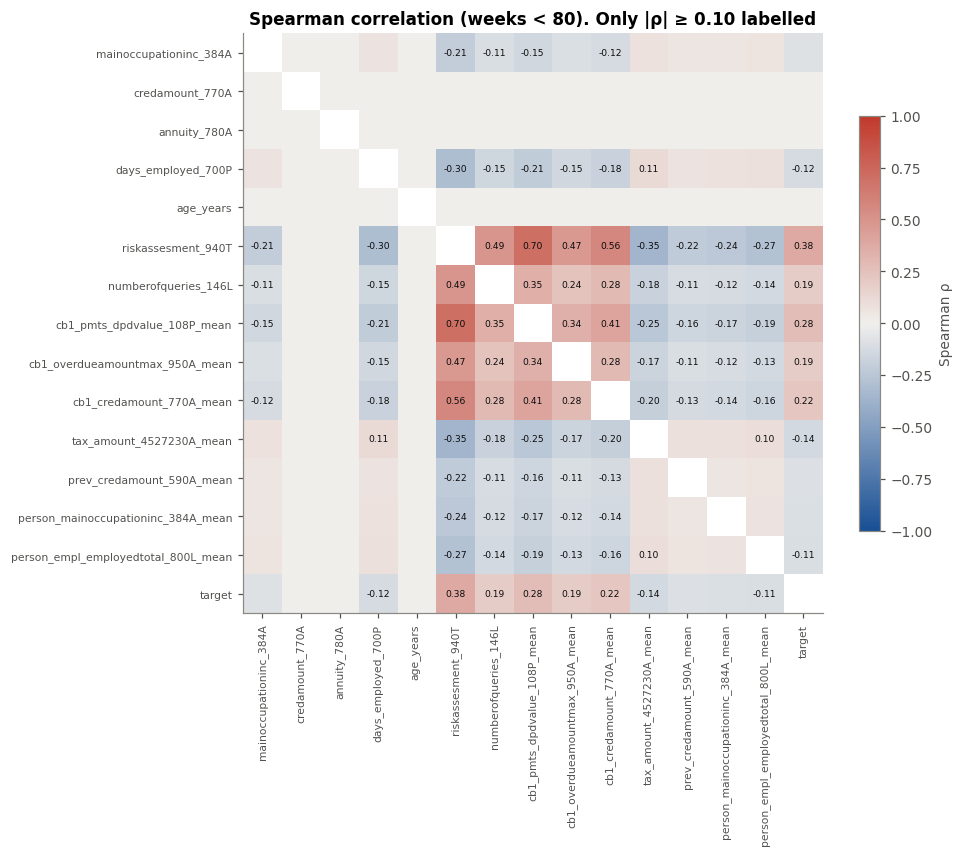

Strongest pairs:
 riskassesment_940T           cb1_pmts_dpdvalue_108P_mean       0.699
                             cb1_credamount_770A_mean          0.563
                             numberofqueries_146L              0.490
                             cb1_overdueamountmax_950A_mean    0.469
cb1_pmts_dpdvalue_108P_mean  cb1_credamount_770A_mean          0.407
riskassesment_940T           target                            0.382
                             tax_amount_4527230A_mean         -0.352
numberofqueries_146L         cb1_pmts_dpdvalue_108P_mean       0.347
cb1_pmts_dpdvalue_108P_mean  cb1_overdueamountmax_950A_mean    0.343
days_employed_700P           riskassesment_940T               -0.303
dtype: float64


In [69]:
# Spearman correlation among the key numerics and the target (fit weeks; pairwise-complete rows)
key = ["mainoccupationinc_384A", "credamount_770A", "annuity_780A", "days_employed_700P", "age_years",
       "riskassesment_940T", "numberofqueries_146L", "cb1_pmts_dpdvalue_108P_mean", "cb1_overdueamountmax_950A_mean",
       "cb1_credamount_770A_mean", "tax_amount_4527230A_mean", "prev_credamount_590A_mean",
       "person_mainoccupationinc_384A_mean", "person_empl_employedtotal_800L_mean", "target"]
corr = fit[key].corr(method="spearman")
shown = corr.mask(np.eye(len(key), dtype=bool))       # hide the trivial diagonal

# Diverging map centered on 0: blue = negative, red = positive
diverging = LinearSegmentedColormap.from_list("blue_gray_red", ["#184f95", "#f0efec", "#c0392b"])
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(shown, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(key)), key, rotation=90, fontsize=7); ax.set_yticks(range(len(key)), key, fontsize=7)
ax.grid(False)
for i in range(len(key)):
    for j in range(len(key)):
        v = corr.iloc[i, j]
        if abs(v) >= 0.1 and i != j:      # label only the correlations worth reading
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6, color="#0b0b0b")
fig.colorbar(im, ax=ax, shrink=0.7, label="Spearman ρ")
ax.set_title("Spearman correlation (weeks < 80). Only |ρ| ≥ 0.10 labelled")
plt.show()

# Upper triangle only (each pair once), strongest first
pairs = corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack().sort_values(key=abs, ascending=False)
print("Strongest pairs:\n", pairs.head(10).round(3))

- **Bureau features move together**: `riskassesment_940T` ↔ DPD mean ρ = 0.70, ↔ past contract size 0.56, ↔ queries 0.49. That's expected
  multicollinearity for logistic regression (regularize), and harmless for trees.
- **Surprise: `credamount_770A`, `annuity_780A` and `age_years` are uncorrelated with everything**, including each other (credit ↔ annuity ρ = 0.00).
  In real lending, annuity comes from the loan amount. Here the generator made them independent noise. So `implied_term` (credit ÷ annuity) is meaningless,
  and `leverage`/`payment_burden` carry signal only through income. Worth telling the team and the Challenge Advisor, because the feature catalog assumes otherwise.
- **Non-bureau signals correlate with the bureau score (ρ −0.2 to −0.35) but hardly with each other** (|ρ| ≤ 0.1). That's the pattern of
  several independent noisy readings of one hidden creditworthiness, which supports *combining* them for thin-file applicants (section 7).
- With `target`: bureau score 0.38, DPD 0.28, contract size 0.22, queries/overdue 0.19 (riskier), then tax income −0.14 and employment −0.12 (safer).

*Caveat:* `.corr()` uses pairwise-complete rows, so every bureau ↔ non-bureau correlation above is computed on **established applicants only** (thin-file applicants have no bureau values).

## 9. Leakage & sanity checks

In [70]:
checks = {}

# 1. Every date in a depth-1/2 table must fall BEFORE the current decision; a later date would leak the future
date_cols = [(name, c) for name, d in train.items() if TABLES[name] > 0 for c in d.columns if c.endswith("D")]
for name, c in date_cols:
    d = train[name][["case_id", c]].merge(base[["case_id", "date_decision"]], on="case_id")
    dt = pd.to_datetime(d[c])
    checks[f"{name}.{c}: dates after date_decision"] = int((dt > d["date_decision"]).sum())
    checks[f"{name}.{c}: min days before decision"] = int((d["date_decision"] - dt).dt.days.min())

# 2. Is approvaldate missing for a reason (e.g. rejected apps)? Missing share per status should differ if so
checks["approvaldate % missing per status (min-max)"] = (
    train["applprev_1"].groupby("status_219L")["approvaldate_319D"]
    .apply(lambda s: round(s.isna().mean() * 100, 1)).agg(["min", "max"]).tolist())

# 3. Train/test have distinct applicants, test is strictly later, and test carries no label
checks["case_ids shared by train and test"] = len(set(base["case_id"]) & set(test_base["case_id"]))
checks["train weeks"] = (int(base["WEEK_NUM"].min()), int(base["WEEK_NUM"].max()))
checks["test weeks"] = (int(test_base["WEEK_NUM"].min()), int(test_base["WEEK_NUM"].max()))
checks["base has target column in test"] = "target" in test_base.columns

# 4. Constant columns, near-constant columns (one value covers > 99% of rows) and duplicate rows
const = [f"{n}.{c}" for n, d in train.items() for c in d.columns if d[c].nunique(dropna=False) <= 1]
near_const = [f"{n}.{c}" for n, d in train.items() for c in d.columns
              if c != "case_id" and d[c].value_counts(normalize=True, dropna=False).iloc[0] > 0.99]
checks["constant columns"] = const or "none"
checks["near-constant columns (top value > 99%)"] = near_const or "none"
checks["duplicate rows (all tables)"] = int(sum(d.duplicated().sum() for d in train.values()))

# 5. Columns that duplicate each other
checks["person_1 num_group1 == personindex_1023L"] = bool((train["person_1"]["num_group1"] == train["person_1"]["personindex_1023L"]).all())
checks["MONTH derivable from date_decision"] = bool((base["date_decision"].dt.strftime("%Y%m").astype(int) == base["MONTH"]).all())

pd.Series(checks, name="result").to_frame()

,result
applprev_1.approvaldate_319D: dates after date_decision,0
applprev_1.approvaldate_319D: min days before decision,30
approvaldate % missing per status (min-max),"[10.0, 10.0]"
case_ids shared by train and test,0
train weeks,"(0, 91)"
test weeks,"(92, 107)"
base has target column in test,False
constant columns,none
near-constant columns (top value > 99%),none
duplicate rows (all tables),0


### Train → test feature shift (Population Stability Index)

PSI compares each feature's distribution in train vs test (deciles fitted on train). Rule of thumb: < 0.1 stable, 0.1–0.25 moderate, > 0.25 large.

In [71]:
def psi(expected, actual, bins=10):
    """Population Stability Index for a numeric column, with decile edges fitted on `expected` (train)."""
    expected, actual = expected.dropna(), actual.dropna()
    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf            # open-ended outer bins catch test values outside train's range
    e = np.histogram(expected, edges)[0] / len(expected)
    a = np.histogram(actual, edges)[0] / len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)   # avoid log(0) for empty bins
    return float(np.sum((a - e) * np.log(a / e)))


def psi_cat(expected, actual):
    """PSI for a categorical column: compare level shares directly."""
    e = expected.value_counts(normalize=True)
    a = actual.value_counts(normalize=True).reindex(e.index, fill_value=0)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))


# Test tables (base and credit_bureau_a_1 were loaded in section 4)
test = {"base": test_base, "credit_bureau_a_1": test_cb1,
        **{n: read_table("test", n) for n in ("static_0", "static_cb_0", "person_1", "applprev_1", "tax_registry_a_1")}}

# Bureau features, plus the features thin-file applicants depend on (including education)
shift_specs = ([("static_0", c) for c in ("mainoccupationinc_384A", "credamount_770A", "annuity_780A",
                                          "days_employed_700P", "education_927M", "maritalstatus_703M")]
               + [("static_cb_0", c) for c in ("riskassesment_940T", "numberofqueries_146L")]
               + [("credit_bureau_a_1", c) for c in ("pmts_dpdvalue_108P", "credamount_770A", "overdueamountmax_950A")]
               + [("person_1", "mainoccupationinc_384A"), ("person_1", "empl_employedtotal_800L"),
                  ("applprev_1", "credamount_590A"), ("tax_registry_a_1", "amount_4527230A")])

# Thin-file applicants in each split, so shift can also be measured inside the segment that matters
train_thin_ids = app.loc[app["thin_file"] == 1, "case_id"]
test_thin_ids = test_base.loc[~test_base["case_id"].isin(test_cb1["case_id"]), "case_id"]

rows = []
for name, c in shift_specs:
    f = psi if pd.api.types.is_numeric_dtype(train[name][c]) else psi_cat
    tr, te = train[name], test[name]
    row = {"table": name, "column": c, "PSI_all": f(tr[c], te[c])}
    if name not in ("static_cb_0", "credit_bureau_a_1"):          # bureau tables have no thin-file rows
        row["PSI_thin_file"] = f(tr.loc[tr["case_id"].isin(train_thin_ids), c],
                                 te.loc[te["case_id"].isin(test_thin_ids), c])
    rows.append(row)
pd.DataFrame(rows).set_index(["table", "column"]).round(4)

PSI_all  PSI_thin_file
table             column                                         
static_0          mainoccupationinc_384A    0.0001         0.0002
                  credamount_770A           0.0001         0.0003
                  annuity_780A              0.0001         0.0004
                  days_employed_700P        0.0000         0.0003
                  education_927M            0.0000         0.0000
                  maritalstatus_703M        0.0001         0.0001
static_cb_0       riskassesment_940T        0.0001            NaN
                  numberofqueries_146L      0.0000            NaN
credit_bureau_a_1 pmts_dpdvalue_108P        0.0000            NaN
                  credamount_770A           0.0000            NaN
                  overdueamountmax_950A     0.0000            NaN
person_1          mainoccupationinc_384A    0.0000         0.0001
                  empl_employedtotal_800L   0.0000         0.0002
applprev_1        credamount_590A           0.0000         0.0000
tax_registry_a_1  amount_4527230A           0.0000         0.0002

**Leakage & sanity: all clear.**
- **No future information**: `approvaldate_319D` is the only date in any depth-1/2 table, and every previous application was approved
  at least 30 days *before* the current decision.
- `approvaldate_319D` is 10% missing **equally across all three statuses**, so missing doesn't mean "rejected". Treat it as plain missing.
- **Train and test are disjoint** (no shared `case_id`) and test is strictly later (weeks 92–107). `test_base` has no `target`.
- **No constant or near-constant columns, no duplicate rows.** Two redundant pairs: `personindex_1023L` = `num_group1` (drop one), and `MONTH` is fully determined by
  `date_decision` (notebook 01 already found this).
- **Features don't shift between train and test** (all PSI < 0.001), including the thin-file features and education, and also
  when measured inside the thin-file segment only. Combined with section 4, the test-period challenge is **purely the thin-file
  default rate moving**, not the applicants changing.

## 10. Findings and implications

### What the data looks like
| | Finding |
|---|---|
| Size | 1M train applicants (weeks 0–91), 200k test (weeks 92–107); 8 tables; clean keys, no duplicates, no sentinels |
| Target | 19.18% default over all training weeks, 19.45% on weeks < 80 (≈ 1 : 4.1). Approve-everyone earns ≈ **+$55/applicant**, the naïve bar to beat |
| Segments | **30% thin-file** (same in train and test). Default 26.5% vs 16.4% established (weeks < 80) |
| Drift | Established flat at 16.4%. **Thin-file falls ~31% → ~20.5%** from 2019 to late 2020. Features and their ranking power stay put, **only the baseline moves** (prior drift) |
| Missingness | 2–40% in some columns but **at random** (no default-rate difference). Only *table-level* absence (no bureau rows) is signal |
| Distributions | Amounts right-skewed (skew ~1.7), plausible outliers; no negatives, no 365243 sentinel. Same distributions in both segments |

### Predictive signals
| Tier | Features | Thin-file? |
|---|---|---|
| Strong (AUC 0.65–0.80) | `riskassesment_940T`, bureau DPD aggregates, past contract amounts, overdue amounts, `numberofqueries_146L`; plus `description_5085714M`, `classificationofcontr_13M` (default rate 2.5% → 44% across levels) | ✗ bureau only |
| Strong, thin-file | **`education_927M`** (AUC ≈ 0.70 inside thin-file; default rate 7.6% → 54% across levels) | ✓ **strongest thin-file signal** |
| Moderate (AUC 0.55–0.60) | declared tax income, employment length (`days_employed_700P`, person `empl_employedtotal_800L`), person & stated income, prior-application amounts | ✓ **works equally well in thin-file** |
| Weak | `leverage`, `payment_burden` (only via income) | ✓ |
| **None** (AUC ≈ 0.50 / flat rates) | `credamount_770A`, `annuity_780A` (also uncorrelated with each other), `implied_term`, `age`, all `credit_bureau_a_2` features, `maritalstatus_703M`, `housingtype_772M`, `status_219L`, `name_4527232M`, record counts (`prev`, `tax`, `person`, # of bureau contracts), `missing_*` flags, `tax_to_stated_income` (catalog: `income_consistency`) | — |

### Implications for the next steps
1. **Feature engineering (notebook 04):** for thin-file applicants, education is the anchor (AUC ≈ 0.70 alone). The moderate non-bureau signals
   add up to ≈ 0.62 on their own but lift education only to ≈ 0.71, so expect modest gains from more thin-file feature work.
   Don't expect lift from the "None" row. Consider dropping `credit_bureau_a_2` aggregates and `num_group1`/`personindex_1023L` duplicates to keep models lean.
2. **The inclusion gap is mainly a calibration/drift problem, not a missing-feature problem.** Thin-file features rank risk the same way they do
   for established applicants, and just as well in every period, but the thin-file baseline keeps falling. Priority levers: per-segment calibration fitted on the **latest** weeks,
   recency weighting or a `WEEK_NUM × thin_file` term, then a segment-aware threshold.
3. **Evaluation:** always report AUC / LogLoss / calibration **per segment** on weeks 80–91. The overall number hides the thin-file problem.
4. **Encoding (notebook 05):** every categorical has ≤ 10 balanced levels, so one-hot works with no rare-level pooling.
   log1p + capping matter for logistic regression only.